# $(SASA) Models - Kmeans$

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pickle
import numpy as np
import pandas as pd

from pmbrl.model2 import Base_Line_Simple_Model
# from pmbrl.model2 import Model, Regularized_Reference_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1689,11,67,"(0.0550547819736606, 0.7277451834527079)","(-0.059, -0.228, 0.039, 0.173)",0,1.0,"(-0.063, -0.419, 0.042, 0.376)",0.0,1.0,"(-0.072, -0.61, 0.049, 0.579)"
2313,0,92,"(0.1771043759930183, 0.8300521931250568)","(0.01, -0.042, -0.015, -0.017)",0,1.0,"(0.009, -0.233, -0.015, 0.167)",1.0,1.0,"(0.005, -0.042, -0.012, -0.023)"
504,56,19,"(0.0642916329828742, 1.239005358213764)","(0.018, 0.399, 0.079, 0.114)",1,1.0,"(0.026, 0.586, 0.081, 0.009)",0.0,1.0,"(0.038, 0.398, 0.081, 0.134)"
1973,21,78,"(0.0956613712139894, 0.231794730405182)","(-0.006, -0.161, 0.038, 0.484)",0,1.0,"(-0.009, -0.372, 0.047, 1.138)",1.0,1.0,"(-0.017, -0.163, 0.07, 0.541)"
1889,18,74,"(0.0909739944949207, 0.7220456982231811)","(-0.079, -0.391, 0.173, 0.67)",1,1.0,"(-0.087, -0.202, 0.187, 0.51)",0.0,1.0,"(-0.091, -0.394, 0.197, 0.747)"
...,...,...,...,...,...,...,...,...,...,...
1944,25,77,"(0.1064004661572971, 0.3173964772630564)","(-0.016, -0.157, -0.113, -0.461)",1,1.0,"(-0.019, 0.048, -0.122, -0.977)",0.0,1.0,"(-0.018, -0.152, -0.141, -0.578)"
1162,60,46,"(0.5759890361457483, 0.539204361971833)","(-0.23, 0.751, 0.017, -1.433)",1,1.0,"(-0.215, 0.951, -0.012, -1.842)",0.0,1.0,"(-0.196, 0.751, -0.049, -1.43)"
345,21,12,"(0.2672189187365715, 1.448682813626807)","(0.01, 0.239, -0.084, -0.316)",0,1.0,"(0.015, 0.053, -0.09, -0.212)",1.0,1.0,"(0.016, 0.24, -0.095, -0.337)"
1065,6,44,"(0.1523965748487631, 0.5191136587315984)","(-0.06, -0.414, 0.025, 0.619)",1,1.0,"(-0.068, -0.219, 0.037, 0.334)",1.0,1.0,"(-0.073, -0.024, 0.044, 0.053)"


In [3]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
# df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
1960,8,78,"(0.0956613712139894, 0.231794730405182)","(0.007, 0.042, -0.018, 0.022)",1,1.0,"(0.008, 0.253, -0.018, -0.62)",0.0,1.0,"(0.013, 0.043, -0.03, -0.003)",0.007,0.042,-0.018,0.022,0.008,0.253,-0.018,-0.620,0.095661,0.231795
1068,9,44,"(0.1523965748487631, 0.5191136587315984)","(-0.073, -0.22, 0.045, 0.359)",1,1.0,"(-0.078, -0.026, 0.052, 0.081)",1.0,1.0,"(-0.078, 0.169, 0.053, -0.196)",-0.073,-0.220,0.045,0.359,-0.078,-0.026,0.052,0.081,0.152397,0.519114
118,2,6,"(0.2451557536988955, 1.3793967951445396)","(-0.001, -0.016, -0.011, -0.016)",0,1.0,"(-0.001, -0.203, -0.012, 0.101)",1.0,1.0,"(-0.005, -0.015, -0.01, -0.019)",-0.001,-0.016,-0.011,-0.016,-0.001,-0.203,-0.012,0.101,0.245156,1.379397
2345,9,93,"(0.2048148528652186, 0.3945260327599418)","(0.041, 0.201, 0.014, -0.334)",0,1.0,"(0.045, 0.001, 0.007, 0.074)",1.0,1.0,"(0.045, 0.201, 0.009, -0.325)",0.041,0.201,0.014,-0.334,0.045,0.001,0.007,0.074,0.204815,0.394526
2258,0,90,"(0.3414097641144769, 0.5159987201834333)","(-0.013, 0.018, 0.002, -0.008)",0,1.0,"(-0.012, -0.179, 0.002, 0.337)",0.0,1.0,"(-0.016, -0.377, 0.008, 0.682)",-0.013,0.018,0.002,-0.008,-0.012,-0.179,0.002,0.337,0.341410,0.515999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,17,50,"(0.3156324259991037, 0.4950654122165437)","(0.096, 0.637, -0.099, -1.23)",0,1.0,"(0.109, 0.441, -0.123, -0.918)",0.0,1.0,"(0.118, 0.245, -0.142, -0.617)",0.096,0.637,-0.099,-1.230,0.109,0.441,-0.123,-0.918,0.315632,0.495065
1955,3,78,"(0.0956613712139894, 0.231794730405182)","(-0.001, -0.169, -0.009, 0.66)",1,1.0,"(-0.005, 0.042, 0.005, 0.024)",1.0,1.0,"(-0.004, 0.252, 0.005, -0.602)",-0.001,-0.169,-0.009,0.660,-0.005,0.042,0.005,0.024,0.095661,0.231795
1463,41,58,"(0.2286484042312217, 0.8574690262302386)","(-0.064, -0.503, -0.136, -0.134)",0,1.0,"(-0.074, -0.692, -0.138, 0.024)",0.0,1.0,"(-0.088, -0.881, -0.138, 0.182)",-0.064,-0.503,-0.136,-0.134,-0.074,-0.692,-0.138,0.024,0.228648,0.857469
2142,8,83,"(0.386432698550154, 0.8914088207818202)","(-0.003, 0.719, -0.014, -0.834)",1,1.0,"(0.012, 0.91, -0.03, -1.045)",0.0,1.0,"(0.03, 0.719, -0.051, -0.844)",-0.003,0.719,-0.014,-0.834,0.012,0.910,-0.030,-1.045,0.386433,0.891409


# Initialization by Random Partitioning

In [4]:
k = 5
models = [Base_Line_Simple_Model() for _ in range(k)]

In [5]:
groups = np.random.randint(low=0, high=k, size=df.episode.unique().shape[0])
df['group'] = np.nan

for i, g in enumerate(groups):
    df.loc[df['episode']==i,'group'] = g
df

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1,group
1960,8,78,"(0.0956613712139894, 0.231794730405182)","(0.007, 0.042, -0.018, 0.022)",1,1.0,"(0.008, 0.253, -0.018, -0.62)",0.0,1.0,"(0.013, 0.043, -0.03, -0.003)",...,0.042,-0.018,0.022,0.008,0.253,-0.018,-0.620,0.095661,0.231795,1.0
1068,9,44,"(0.1523965748487631, 0.5191136587315984)","(-0.073, -0.22, 0.045, 0.359)",1,1.0,"(-0.078, -0.026, 0.052, 0.081)",1.0,1.0,"(-0.078, 0.169, 0.053, -0.196)",...,-0.220,0.045,0.359,-0.078,-0.026,0.052,0.081,0.152397,0.519114,3.0
118,2,6,"(0.2451557536988955, 1.3793967951445396)","(-0.001, -0.016, -0.011, -0.016)",0,1.0,"(-0.001, -0.203, -0.012, 0.101)",1.0,1.0,"(-0.005, -0.015, -0.01, -0.019)",...,-0.016,-0.011,-0.016,-0.001,-0.203,-0.012,0.101,0.245156,1.379397,1.0
2345,9,93,"(0.2048148528652186, 0.3945260327599418)","(0.041, 0.201, 0.014, -0.334)",0,1.0,"(0.045, 0.001, 0.007, 0.074)",1.0,1.0,"(0.045, 0.201, 0.009, -0.325)",...,0.201,0.014,-0.334,0.045,0.001,0.007,0.074,0.204815,0.394526,4.0
2258,0,90,"(0.3414097641144769, 0.5159987201834333)","(-0.013, 0.018, 0.002, -0.008)",0,1.0,"(-0.012, -0.179, 0.002, 0.337)",0.0,1.0,"(-0.016, -0.377, 0.008, 0.682)",...,0.018,0.002,-0.008,-0.012,-0.179,0.002,0.337,0.341410,0.515999,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,17,50,"(0.3156324259991037, 0.4950654122165437)","(0.096, 0.637, -0.099, -1.23)",0,1.0,"(0.109, 0.441, -0.123, -0.918)",0.0,1.0,"(0.118, 0.245, -0.142, -0.617)",...,0.637,-0.099,-1.230,0.109,0.441,-0.123,-0.918,0.315632,0.495065,3.0
1955,3,78,"(0.0956613712139894, 0.231794730405182)","(-0.001, -0.169, -0.009, 0.66)",1,1.0,"(-0.005, 0.042, 0.005, 0.024)",1.0,1.0,"(-0.004, 0.252, 0.005, -0.602)",...,-0.169,-0.009,0.660,-0.005,0.042,0.005,0.024,0.095661,0.231795,1.0
1463,41,58,"(0.2286484042312217, 0.8574690262302386)","(-0.064, -0.503, -0.136, -0.134)",0,1.0,"(-0.074, -0.692, -0.138, 0.024)",0.0,1.0,"(-0.088, -0.881, -0.138, 0.182)",...,-0.503,-0.136,-0.134,-0.074,-0.692,-0.138,0.024,0.228648,0.857469,2.0
2142,8,83,"(0.386432698550154, 0.8914088207818202)","(-0.003, 0.719, -0.014, -0.834)",1,1.0,"(0.012, 0.91, -0.03, -1.045)",0.0,1.0,"(0.03, 0.719, -0.051, -0.844)",...,0.719,-0.014,-0.834,0.012,0.910,-0.030,-1.045,0.386433,0.891409,1.0


## Initial Training 

In [6]:
def train_models(models, train_dataset):
    train_data = [None for _ in models]

    for g, model in enumerate(models):
        # print('train model: ', g)
        group_data = train_dataset.loc[train_dataset['group']==g]
        x, y = model.get_features_targets(group_data)
        trainer = model.train(x, y, num_epochs=1000)
        train_data[g] = data.get_training_data(trainer, inference_schema=model.inference_schema)
    
    return train_data


In [7]:
train_data = train_models(models, df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]])

train_data[0].head()

,epoch,mse_s,transition,reward
0,0,"[0.1976131796836853, 0.3519060015678406, 0.064...",1.725362,0.256555
1,1,"[0.19384771585464478, 0.34875330328941345, 0.0...",1.711438,0.258897
2,2,"[0.19014550745487213, 0.3456386923789978, 0.06...",1.697674,0.261268
3,3,"[0.18650756776332855, 0.3425789773464203, 0.05...",1.684065,0.263666
4,4,"[0.18293164670467377, 0.3395811915397644, 0.05...",1.670612,0.266089


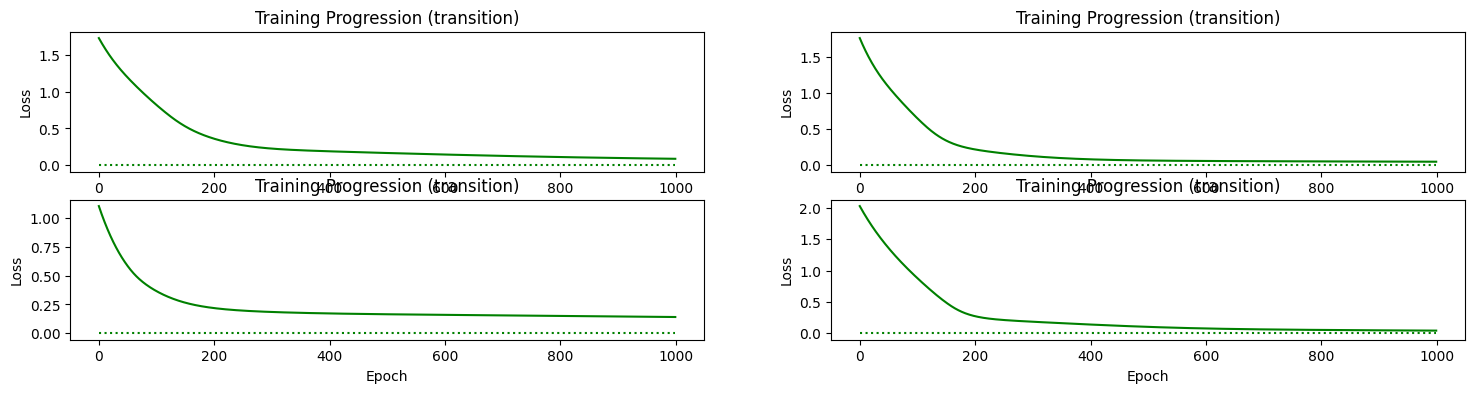

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18, 4))

data.plot_training_loss(axs[0][0], train_data[0].transition)
data.plot_training_loss(axs[0][1], train_data[1].transition)
data.plot_training_loss(axs[1][0], train_data[2].transition)
data.plot_training_loss(axs[1][1], train_data[3].transition)

plt.show()

# Predict 

In [9]:
def evaluate(models, df):
    def predict(model):
        prediction_dataset = df.copy()
        prediction_dataset[model.grouped_targets_lables] = prediction_dataset.apply(lambda row: data._predict_from_row(row, model), axis=1, result_type='expand')
        return prediction_dataset

    predictions = [predict(m) for m in models]

    prediction_dataset = df.copy()
    for i, pred in enumerate(predictions):
        prediction_dataset[f'estimated_s_model_{i}'] = pred['estimated_s']
        
        results = data.get_evaluation_metrics(pred, p=False)
        prediction_dataset[f'rse_model_{i}'] = results['rse']
        prediction_dataset[f'rse_normalized_model_{i}'] = results['rse_normalized']

        prediction_dataset[f'rse_s0_model_{i}'] = results['rse_s0']
        prediction_dataset[f'rse_s1_model_{i}'] = results['rse_s1']
        prediction_dataset[f'rse_s2_model_{i}'] = results['rse_s2']
        prediction_dataset[f'rse_s3_model_{i}'] = results['rse_s3']

        prediction_dataset[f'rse_s0_normalized_model_{i}'] = results['rse_s0_normalized']
        prediction_dataset[f'rse_s1_normalized_model_{i}'] = results['rse_s1_normalized']
        prediction_dataset[f'rse_s2_normalized_model_{i}'] = results['rse_s2_normalized']
        prediction_dataset[f'rse_s3_normalized_model_{i}'] = results['rse_s3_normalized']


    return prediction_dataset

In [10]:
prediction_dataset = evaluate(models, df)
prediction_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_model_4,rse_normalized_model_4,rse_s0_model_4,rse_s1_model_4,rse_s2_model_4,rse_s3_model_4,rse_s0_normalized_model_4,rse_s1_normalized_model_4,rse_s2_normalized_model_4,rse_s3_normalized_model_4
1960,8,78,"(0.0956613712139894, 0.231794730405182)","(0.007, 0.042, -0.018, 0.022)",1,1.0,"(0.008, 0.253, -0.018, -0.62)",0.0,1.0,"(0.013, 0.043, -0.03, -0.003)",...,0.464,0.484795,0.002,0.058,0.004,0.400,0.404246,0.429169,0.508393,0.597371
1068,9,44,"(0.1523965748487631, 0.5191136587315984)","(-0.073, -0.22, 0.045, 0.359)",1,1.0,"(-0.078, -0.026, 0.052, 0.081)",1.0,1.0,"(-0.078, 0.169, 0.053, -0.196)",...,0.119,0.482843,0.028,0.008,0.008,0.075,0.415071,0.420457,0.517986,0.577860
118,2,6,"(0.2451557536988955, 1.3793967951445396)","(-0.001, -0.016, -0.011, -0.016)",0,1.0,"(-0.001, -0.203, -0.012, 0.101)",1.0,1.0,"(-0.005, -0.015, -0.01, -0.019)",...,0.310,0.492943,0.005,0.026,0.023,0.256,0.405495,0.423593,0.553957,0.588726
2345,9,93,"(0.2048148528652186, 0.3945260327599418)","(0.041, 0.201, 0.014, -0.334)",0,1.0,"(0.045, 0.001, 0.007, 0.074)",1.0,1.0,"(0.045, 0.201, 0.009, -0.325)",...,0.105,0.483422,0.013,0.021,0.011,0.060,0.408826,0.422722,0.525180,0.576960
2258,0,90,"(0.3414097641144769, 0.5159987201834333)","(-0.013, 0.018, 0.002, -0.008)",0,1.0,"(-0.012, -0.179, 0.002, 0.337)",0.0,1.0,"(-0.016, -0.377, 0.008, 0.682)",...,0.116,0.491756,0.005,0.025,0.026,0.060,0.405495,0.423419,0.561151,0.576960


In [11]:
def reagroup(prediction_dataset):
    agg_results = prediction_dataset[['episode'] + [
    f'rse_model_{i}' for i,_ in enumerate(models)
    #     'rse_model_0',
    #     'rse_model_1',
    #     'rse_model_2',
    #     'rse_model_3',
    #     'rse_model_4',
    ]].groupby('episode').mean().reset_index()

    agg_results['best_model'] = agg_results.apply(lambda row: np.argmin(row[1:].values), axis=1)
    # print(agg_results['best_model'].value_counts())

    prediction_dataset['best_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_model.values[0],axis=1)
    prediction_dataset['best_rse'] = prediction_dataset.apply(lambda row: row[f'rse_model_{row.best_model}'],axis=1)

    return prediction_dataset

In [12]:
prediction_dataset = reagroup(prediction_dataset)
prediction_dataset[['best_rse']].describe()

,best_rse
count,2504.000000
mean,0.193971
std,0.227336
min,0.009000
25%,0.090750
50%,0.147000
75%,0.228250
max,4.355000


# LOOP

In [13]:

# while True: 
for i in range(50): 
    check = prediction_dataset[prediction_dataset['group'] != prediction_dataset['best_model']].shape[0]
    print(f'({i}) epis_changed: {check}')
    if check == 0:
        break
    

    train_df = prediction_dataset[['s', 's_', 's__', 'a', 'a_', 'r', 'p']].copy()
    train_df['group'] = prediction_dataset['best_model']
    train_data = train_models(models, train_df)

    prediction_dataset = evaluate(models, prediction_dataset)

    prediction_dataset = reagroup(prediction_dataset)
    print(prediction_dataset[['best_rse']].mean())
    

(0) epis_changed: 1612
best_rse    0.115398
dtype: float64
(1) epis_changed: 1759
best_rse    0.090088
dtype: float64
(2) epis_changed: 1824
best_rse    0.07532
dtype: float64
(3) epis_changed: 1819
best_rse    0.061295
dtype: float64
(4) epis_changed: 1811
best_rse    0.054504
dtype: float64
(5) epis_changed: 1822
best_rse    0.050615
dtype: float64
(6) epis_changed: 1850
best_rse    0.046218
dtype: float64
(7) epis_changed: 1811
best_rse    0.042257
dtype: float64
(8) epis_changed: 1796
best_rse    0.038655
dtype: float64
(9) epis_changed: 1796
best_rse    0.035925
dtype: float64
(10) epis_changed: 1796
best_rse    0.034452
dtype: float64
(11) epis_changed: 1796
best_rse    0.033649
dtype: float64
(12) epis_changed: 1796
best_rse    0.03315
dtype: float64
(13) epis_changed: 1796
best_rse    0.032538
dtype: float64
(14) epis_changed: 1796
best_rse    0.031996
dtype: float64
(15) epis_changed: 1796
best_rse    0.031651
dtype: float64
(16) epis_changed: 1796
best_rse    0.031259
dtype: 

# Export Model 

In [14]:
import pickle

exp = {
    "data": prediction_dataset,
    "model": models 
}

nome_do_arquivo = 'kmodels_10.pkl'
with open(nome_do_arquivo, 'wb') as arquivo:
    pickle.dump(exp, arquivo)